   지역        총인구         병원수
0  대구   200000.0   96.666667
1  부산   300000.0   80.000000
2  서울  1000000.0  150.000000
3  인천   500000.0   60.000000


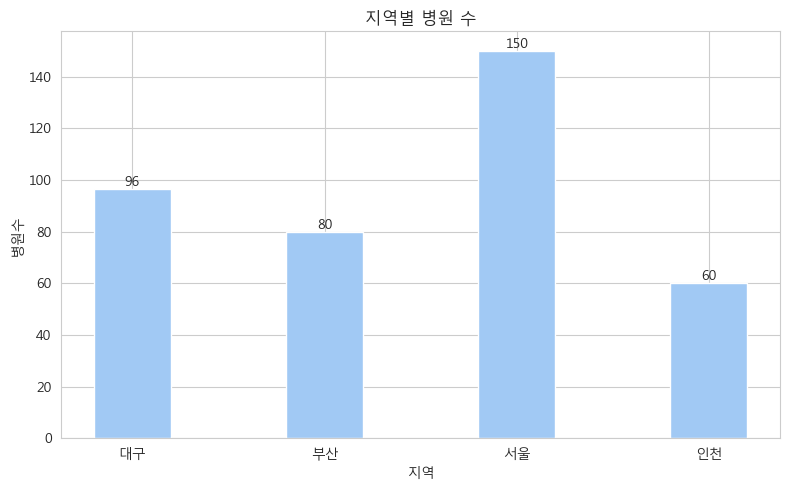

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# ---------------------------
# 2. 데이터 병합 (지역 기준)
# how='outer' → 모든 지역 포함
# ---------------------------
merged= pd.merge(df1, df2, on="지역", how="outer")

# ---------------------------
# 3. 결측치 처리
# 총인구가 없는 값 → 평균으로 채우기
# ---------------------------
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
# 결과 확인
print(merged)

# ---------------------------
# 4. 한글 깨짐 방지 설정
# ---------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#--------------------------------
# 차트 이쁘게 꾸미기
#  배경 + 색상 자동 적용
#--------------------------------
#plt.style.use('ggplot')
#plt.style.use('default')
#plt.style.use('seaborn-v0_8')
#plt.style.use('dark_background')
#plt.style.use('fast')


# ---------------------------
# 5. 그래프 크기 설정
# ---------------------------
plt.figure(figsize=(8, 5))

# ---------------------------
# 6. 막대그래프 생성
# x축 → 지역
# y축 → 병원수
# ---------------------------
bars = plt.bar(merged["지역"], merged["병원수"], width=0.4)

# ---------------------------
# 7. 그래프 꾸미기
# rotation=90 글자를 통째로 세로로 회전
# labelpad=15 차트와 간격 넓히기
# ---------------------------

plt.title("지역별 병원 수")
plt.xlabel("지역")
plt.ylabel("병원수")


# 막대 위에 값 표시


# X축 회전
#plt.xticks(rotation=45)

# 여백 자동 조정
plt.tight_layout()

# ---------------------------
# 8. 이미지 저장 (핵심)
# ---------------------------
plt.savefig("hospital_chart.png", dpi=300)

# ---------------------------
# 9. 그래프 출력
# ---------------------------
plt.show()

   지역        총인구         병원수
0  대구   200000.0   96.666667
1  부산   300000.0   80.000000
2  서울  1000000.0  150.000000
3  인천   500000.0   60.000000
96.66666666666667
80.0
150.0
60.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_24392\432177778.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


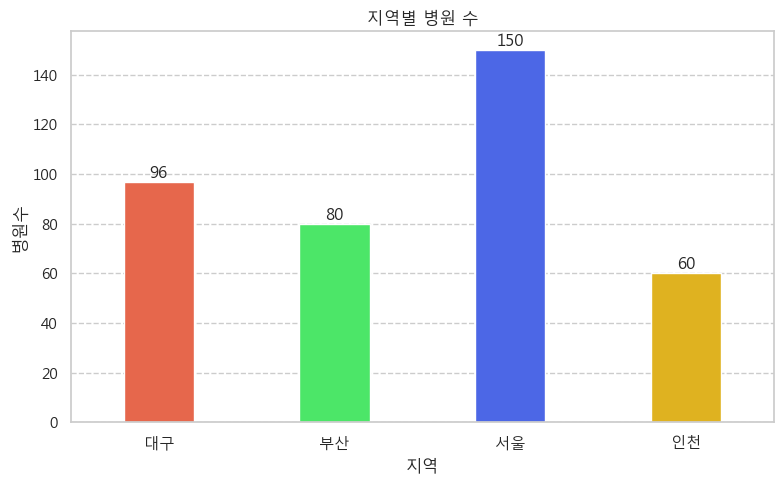

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

merged = pd.merge(df1, df2, on="지역", how="outer")

merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

print(merged)

# ---------------------------
# 4. Seaborn 스타일 + 폰트 설정 (중요)
# ---------------------------
sns.set_style('whitegrid')   # 배경 스타일 설정
sns.set_palette('pastel')    # 색상 스타일 설정

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------
# 5. 그래프 크기 설정
# ---------------------------
plt.figure(figsize=(8, 5))

# ---------------------------
# 6. Seaborn 막대그래프
# ---------------------------
# ax = sns.barplot(
#                  x='지역', 
#                  y='병원수', 
#                  data=merged, 
#                  width=0.4, 
#                  palette=['red', 'blue', 'green', 'orange']
#                 )

plt.grid(linestyle='--')

ax = sns.barplot(
    x='지역',
    y='병원수',
    data=merged,
    width=0.4,
    palette=['#FF5733', '#33FF57', '#3357FF', '#FFC300']
)

plt.title("지역별 병원 수")
plt.xlabel("지역")
plt.ylabel("병원수")

for i in range(len(merged["병원수"])):
    v = merged["병원수"][i]  # i번째 병원수 값
    print(v)
    ax.text(
        i,        # x 위치 (막대의 위치: 0, 1, 2, 3 ...)
        v,        # y 위치 (막대 높이)
        int(v),   # 표시할 값
        ha='center',  # 가운데 정렬
        va='bottom'   # 막대 위쪽에 표시
    )

# 그래프 요소들이 겹치지 않게 자동으로 간격을 조정해주는 기능
plt.tight_layout()
plt.show()